In [1]:
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import resample

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [2]:
seed = 42

device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 32

# EDA

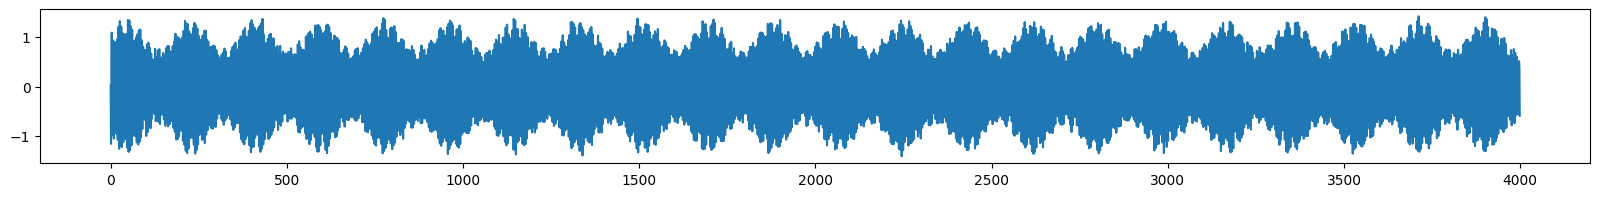

In [3]:
df = pd.read_csv("train_data.csv")

sample = df[df["Song_ID"] == 23]["Data_y"].values

plt.figure(figsize=(20, 2))
plt.plot(sample)

In [4]:
song_lengths = df.groupby("Song_ID").size()
print(song_lengths.value_counts())
print(f"Min: {song_lengths.min()}, Max: {song_lengths.max()}")

4000    500
Name: count, dtype: int64
Min: 4000, Max: 4000


In [5]:
def audio_to_file(x, wav_fixed):
    data = x
    fs = 200  # nu schimba, suntele sunt generate la 200hz
    new_fs = 44100  # nu schimba, testat se aud cel mai bine pe 44,1khz (sure bro?)
    n_samples = int(len(data) * new_fs / fs)
    data_resampled = resample(data, n_samples)
    sf.write(wav_fixed, data_resampled, new_fs)

In [6]:
audio_to_file(sample, "sample.wav")

In [7]:
mean_val = df["Data_y"].mean()
std_val = df["Data_y"].std()

print(f"Mean: {mean_val}, Std: {std_val}")

Mean: 5.57581615772914e-05, Std: 0.725650998202237


# Dataset

In [8]:
class AudioDataset(Dataset):
    def __init__(self, is_train: bool):
        super().__init__()
        self.is_train = is_train
        self.df = pd.read_csv("train_data.csv" if is_train else "test_data.csv")
        self.song_ids = sorted(self.df["Song_ID"].unique())

    def __getitem__(self, idx):
        song_id = self.song_ids[idx]
        sample = self.df[self.df["Song_ID"] == song_id]

        X = torch.tensor(sample["Data_X" if self.is_train else "Data"].values, dtype=torch.float32)

        if self.is_train:
            y = torch.tensor(sample["Data_y"].values, dtype=torch.float32)
            return {"X": X, "y": y}
        return {"X": X, "song_id": song_id}

    def __len__(self):
        return len(self.song_ids)

In [9]:
train_ds = AudioDataset(is_train=True)
test_ds = AudioDataset(is_train=False)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [10]:
x = next(iter(train_loader))
{k: x[k].shape for k in x}

{'X': torch.Size([32, 4000]), 'y': torch.Size([32, 4000])}

# Model

In [11]:
class ReconstructionModel(nn.Module):
    def __init__(self, n_hidden: int = 128):
        super().__init__()

        self.input_proj = nn.Linear(1, n_hidden)
        self.lstm = nn.LSTM(
            input_size=n_hidden,
            hidden_size=n_hidden,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True,
        )

        self.fc = nn.Linear(n_hidden * 2, 1)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # x: (batch, seq_len) -> (batch, seq_len, 1)
        x = x.unsqueeze(-1)
        x = self.input_proj(x)
        x = self.dropout(x)

        out, _ = self.lstm(x)

        out = self.dropout(out)
        return self.fc(out).squeeze(-1)

In [12]:
model = ReconstructionModel().to(device)

model(x["X"].to(device)).shape

torch.Size([32, 4000])

# Training

In [13]:
lr = 2e-3
epochs = 90

losses, lrs = [], []
best_loss = 5

In [14]:
criterion = nn.MSELoss()
optim = torch.optim.AdamW(model.parameters(), lr=lr)
scaler = torch.amp.GradScaler(device)

In [15]:
for epoch in range(1, epochs+1):
    total_loss = 0.0
    model.train()
    for sample in tqdm(train_loader):
        X, y = sample["X"].to(device), sample["y"].to(device)

        with torch.amp.autocast(device):
            out = model(X)
            loss = criterion(out, y)

        optim.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()

        total_loss += loss.item()
        losses.append(loss.item())
        lrs.append(optim.param_groups[0]["lr"])

    total_loss = total_loss / len(train_loader)
    if total_loss < best_loss:
        best_loss = total_loss
        torch.save(model.state_dict(), "model.pt")
    print(f"Epoch {epoch}, loss={total_loss:.4f}")

100%|██████████| 16/16 [00:02<00:00,  6.34it/s]


Epoch 1, loss=0.2743


100%|██████████| 16/16 [00:02<00:00,  6.90it/s]


Epoch 2, loss=0.1303


100%|██████████| 16/16 [00:02<00:00,  6.86it/s]


...

Epoch 88, loss=0.0413


100%|██████████| 16/16 [00:02<00:00,  6.89it/s]


Epoch 89, loss=0.0419


100%|██████████| 16/16 [00:02<00:00,  6.90it/s]

Epoch 90, loss=0.0525


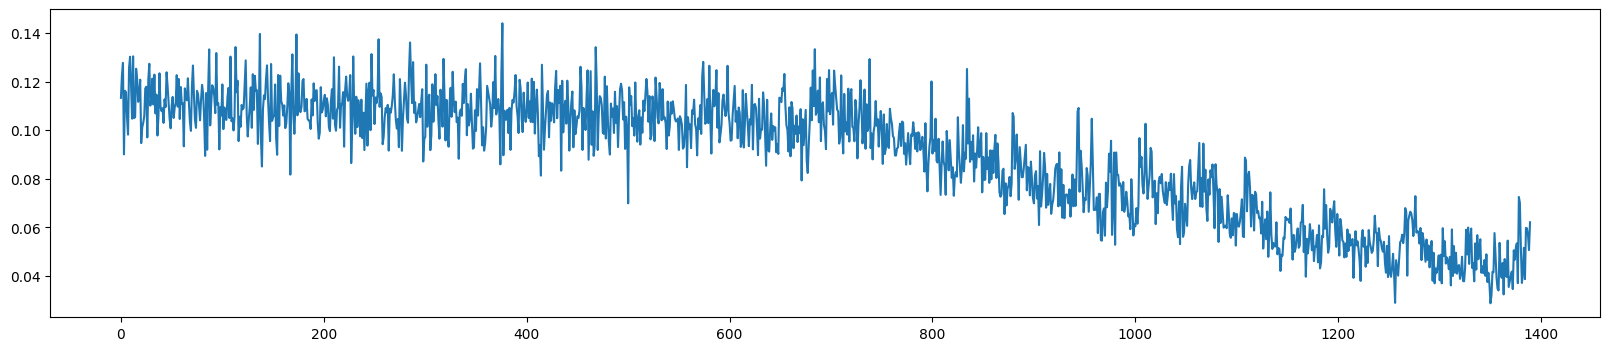

In [16]:
plt.figure(figsize=(20, 4))
plt.plot(losses[50:])

# Submission

In [17]:
model.load_state_dict(torch.load("model.pt"))

<All keys matched successfully>

In [18]:
model.eval()
submission_rows = []

with torch.no_grad():
    for batch in tqdm(test_loader):
        X = batch["X"].to(device)
        song_ids = batch["song_id"]

        preds = model(X)

        for i, song_id in enumerate(song_ids):
            song_preds = preds[i].cpu().numpy()
            for iterator, val in enumerate(song_preds):
                submission_rows.append(
                    {
                        "subtaskID": 1,
                        "datapointID": f"({song_id}, {iterator})",
                        "answer": round(float(val), 5),
                    }
                )

submission_df = pd.DataFrame(submission_rows)
submission_df.to_csv("submission.csv", index=False)
print(f"Submission shape: {submission_df.shape}")
print(submission_df.head())

100%|██████████| 2/2 [00:00<00:00,  2.81it/s]


Submission shape: (160000, 3)
   subtaskID datapointID   answer
0          1      (0, 0)  0.15170
1          1      (0, 1) -0.59358
2          1      (0, 2)  0.93124
3          1      (0, 3) -0.91311
4          1      (0, 4)  0.81114
